# MQTT-Discovery vs UPnP

## Load log files

### Imports

In [28]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Costants

In [29]:
log_dir = "../logs"
upnp_dynamic_mx = log_dir + "/control_latency"
upnp_zero_mx = log_dir + "/control_latency_mx0"
gena = log_dir + "/gena"
mqtt = log_dir + "/mqtt"

### Utility functions

In [30]:
def parse_filename(filename: str) -> tuple[int, int, int]:
    match = re.search("d-[0-9]+_(u|m)-[0-9]+_(q-[0-9]+)?", filename)

    result = ()
    if match:
        match_str = match.group()
        params = match_str.removeprefix("d-").replace("u-", "").replace("m-", "").replace("q-", "").split("_")

        result
        if "m-" in match_str:
            result = int(params[0]), int(params[1]), int(params[2])
        else:
            result = int(params[0]), int(params[1]), None
            

    return result

In [31]:
def parse_file(file: Path) -> list[any]:
    result = []
    with open(file, 'r') as in_file:
        for line in in_file:
            try:
                line = line.strip()

                if line:
                    data = json.loads(line)
                    
                    result.append(data)
            except:
                None
    return result

In [32]:
def load_log_file(path: str) -> dict:
    log_dir_path = Path(path)
    result = {}

    for f in log_dir_path.iterdir():
        if f.is_file() and f.name.startswith("control") and f.name.endswith(".log"):
            params = parse_filename(f.name)
            
            if params[2] == None:
                result.setdefault(params[0], {}).setdefault(params[1], []).append(parse_file(f))
            else:
                result.setdefault(params[0], {}).setdefault(params[1], {}).setdefault(params[2], []).append(parse_file(f))
    
    return result

In [33]:
def convert_strings_to_milliseconds(str: str) -> float:
    if str.endswith("ns"):  # Nanoseconds
        return float(str[:-2])/1000000
    elif str.endswith("µs"):  # Microseconds
        return float(str[:-2])/1000
    elif str.endswith("ms"):  # Milliseconds
        return float(str[:-2])
    elif str.endswith("s"):  # Seconds
        return float(str[:-2])*1000
    else:  # Seconds
        return float(str[:-1])

## UPnP Analysis

In [34]:
upnp_dynamic_mx_tests = load_log_file(upnp_dynamic_mx)
#upnp_dynamic_mx_tests = load_log_file(upnp_zero_mx)

### Data filtering

#### Filter latency related data

In [35]:
latency_data = {}

for device_config, controls in upnp_dynamic_mx_tests.items():
    latency_controls = {}
    for control_config, tests in controls.items():
        latency_tests = []
        for test in tests:
            latency_values = []
            for value in test:
                match = re.search("RPC Elapsed time: [0-9]+(.[0-9]+)?.s$", value["msg"])
                if match:
                    latency_values.append(convert_strings_to_milliseconds(match.group().split(":")[1].strip())) #TODO make a number from it
            
            if len(latency_values) > 0:
                latency_tests.append(latency_values)
        
        lens = np.array([len(item) for item in latency_tests])
        if len(lens) > 0:
            mask = np.arange(lens.max()) < lens[:, None]
            result = np.zeros(mask.shape, dtype=float)
            result[mask] = np.concatenate(latency_tests)
            latency_controls[control_config] = result

    latency_data[device_config] = latency_controls

#### Filter robustness related data

In [36]:
robustness_data = {}

for device_config, controls in upnp_dynamic_mx_tests.items():
    robustness_controls = {}
    for control_config, tests in controls.items():
        robustness_tests = []
        for test in tests:
            robustness_values = []
            for value in test:
                match = re.search("Found [0-9]+ devices$", value["msg"])
                if match:
                    robustness_values.append(match.group().removeprefix("Found").removesuffix("devices").strip()) #TODO make a number from it
            
            if len(robustness_values) > 0:
                robustness_tests.append(robustness_values)
        
        lens = np.array([len(item) for item in robustness_tests])
        if len(lens) > 0:
            mask = np.arange(lens.max()) < lens[:, None]
            result = np.zeros(mask.shape, dtype=int)
            result[mask] = np.concatenate(robustness_tests)
            robustness_controls[control_config] = result

    robustness_data[device_config] = robustness_controls

robustness_data

{80: {40: array([[ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ..., 80, 79, 79],
         [ 0,  0,  0, ...,  0,  0, 79],
         ...,
         [ 0,  0,  0, ..., 80, 80, 80],
         [ 0,  0,  0, ...,  0, 79, 80],
         [ 0,  0,  0, ...,  0,  0,  0]]),
  80: array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]),
  70: array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]),
  8: array([[ 0,  0,  0,  0,  0, 78, 80, 78],
         [ 0,  0,  0,  0,  0,  0, 77, 80],
         [ 0,  0,  0,  0,  0,  0, 77, 79],
         [ 0,  0,  0,  0, 80, 80, 80, 78],
         [ 0,  0,  0,  0, 80, 79, 79, 78],
         [ 0,  0,  0,  0,  0,  0, 79, 78],
         [ 0,  0,  0,  0, 7

### Data visualization

#### Latency visualiazation

In [37]:
values_device = []
values_control = []

values_avg = []
values_max = []
values_min = []
values_97_5 = []
values_2_5 = []

for device_config, controls in latency_data.items():
    for control_config, values in controls.items():
        values_device.append(device_config)
        values_control.append(control_config)
        
        values_avg.append(np.mean(values[values != 0]))
        values_max.append(np.max(values[values != 0]))
        values_min.append(np.min(values[values != 0]))

        value_2_5, value_97_5 = np.percentile(values[values != 0], [2.5, 97.5])

        values_97_5.append(value_97_5)
        values_2_5.append(value_2_5)


latency_data_pd = pd.DataFrame({"device_config": values_device,
                                "control_config": values_control,
                                "average_value": values_avg,
                                "max_value": values_max,
                                "min_value": values_min,
                                "97.5_perc": values_97_5,
                                "2.5_perc": values_2_5
                                }).sort_values(by=["device_config", "control_config"])

latency_data_pd

,device_config,control_config,average_value,max_value,min_value,97.5_perc,2.5_perc
208,1,1,61.578714,715.931697,4.624999,536.737896,4.625787
218,1,2,57.071616,337.420384,3.978813,311.039164,4.115907
216,1,3,28.452373,312.476885,4.069862,298.580947,4.341807
215,1,4,32.908597,204.413728,4.004403,110.275371,4.317899
213,1,5,51.243876,415.095038,3.849874,413.359858,4.441064
...,...,...,...,...,...,...,...
66,100,9,28.320086,1928.741660,4.372984,224.766835,7.724244
55,100,10,28.389551,1534.711100,4.674085,225.320026,7.721928
63,100,20,25.239354,739.565282,4.051161,215.736550,8.131025
57,100,30,29.003732,1911.832040,4.207332,221.988396,9.179161


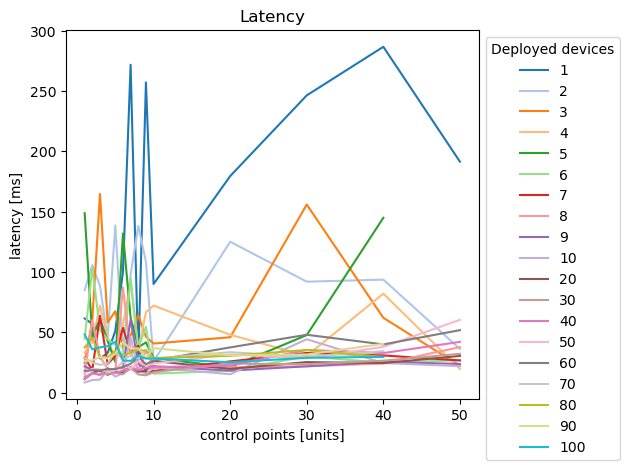

In [38]:
device_configs = latency_data_pd["device_config"].unique()
device_configs.sort()

fig, ax = plt.subplots()

labels_colors = plt.cm.tab20(np.linspace(0, 1, 20))
count = 0
for device_config in device_configs:
    config = latency_data_pd[latency_data_pd["device_config"] == device_config]
    
    ax.plot(config["control_config"], config["average_value"], label=f"{device_config}", color=labels_colors[count])

    count += 1

ax.set_title(f"Latency")
ax.set_xlabel("control points [units]")
ax.set_ylabel("latency [ms]")
ax.legend(title="Deployed devices", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

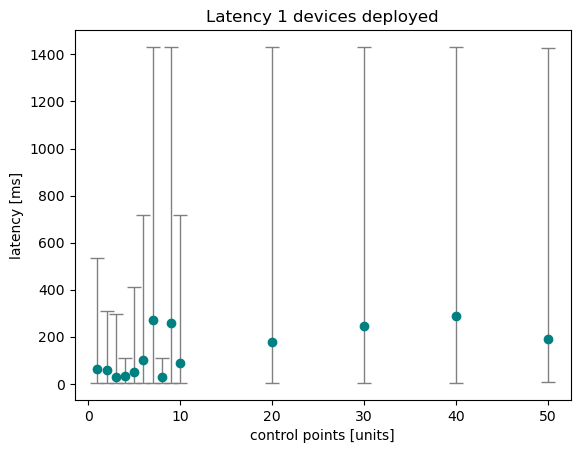

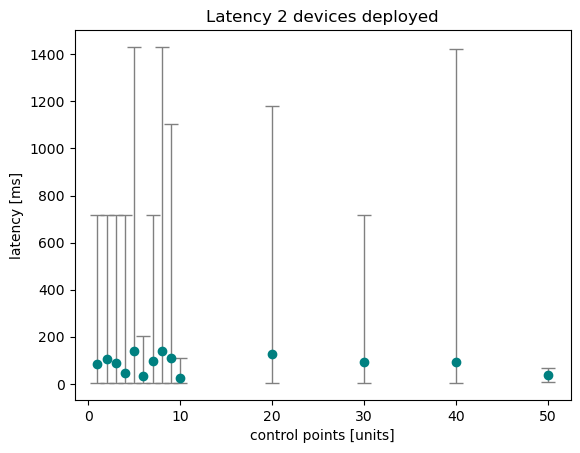

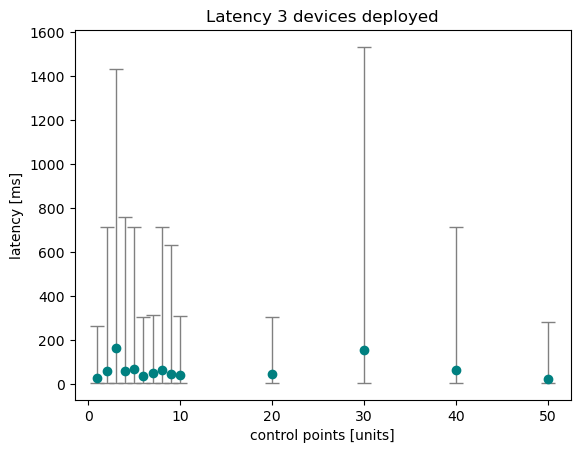

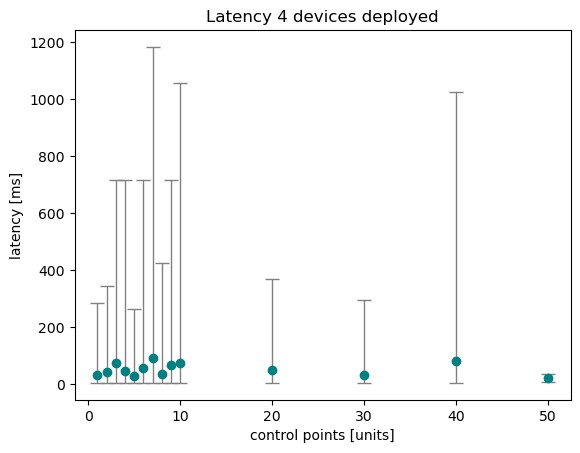

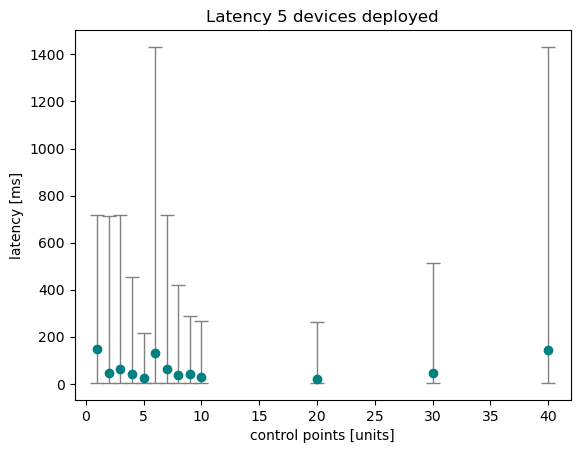

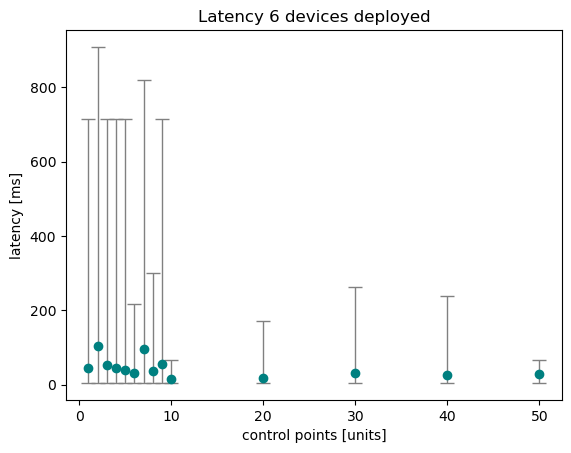

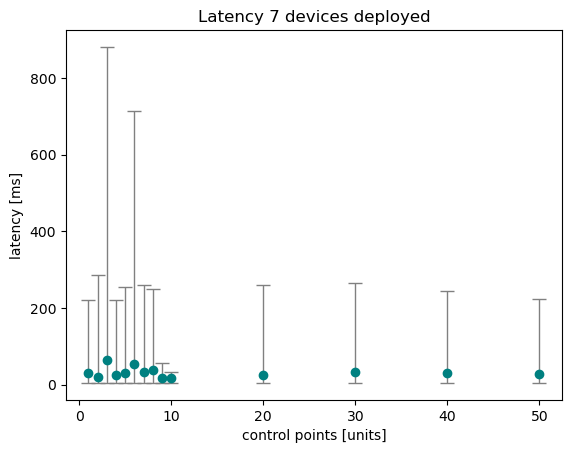

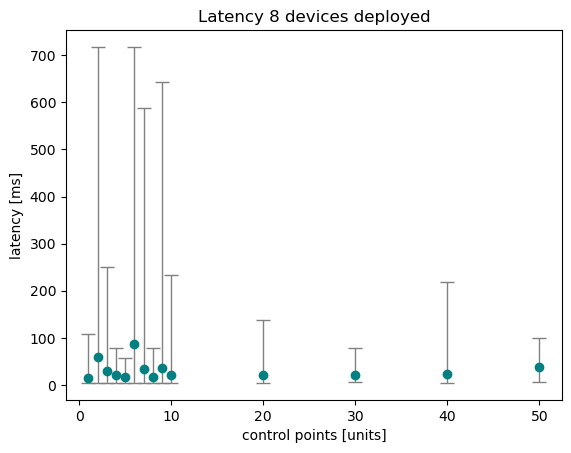

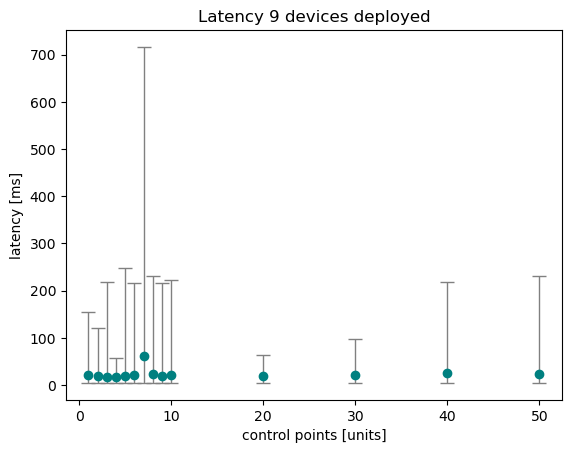

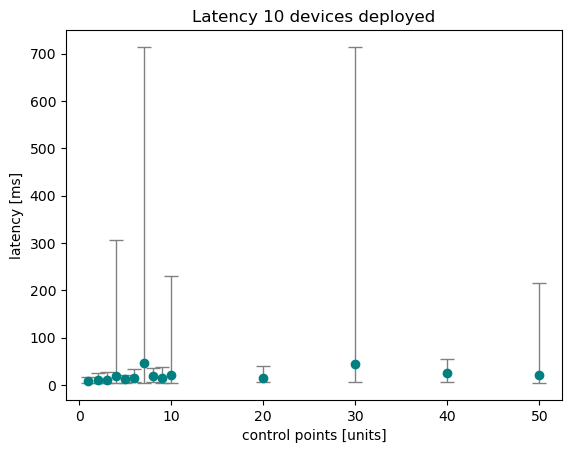

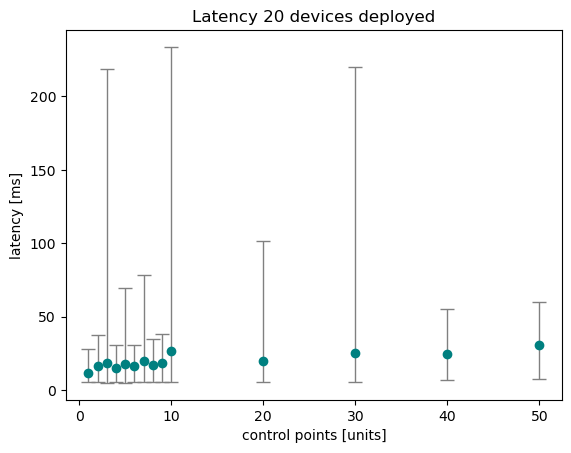

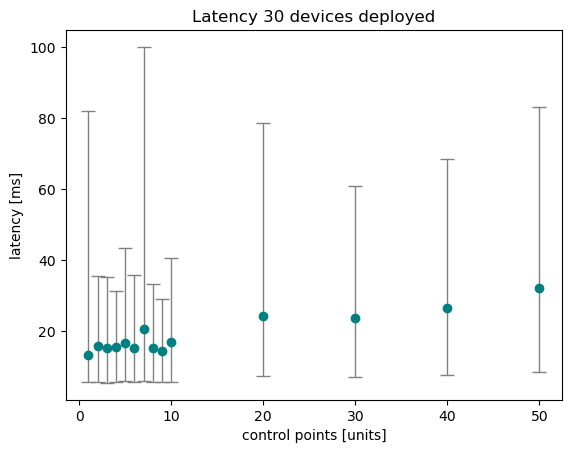

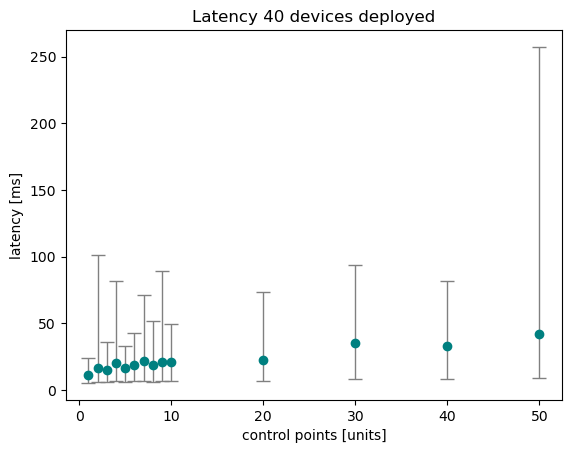

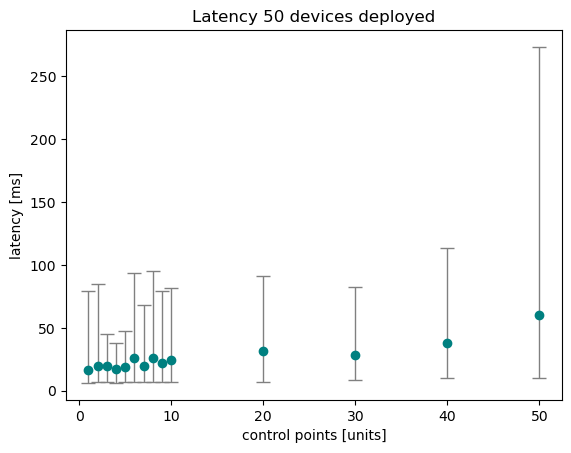

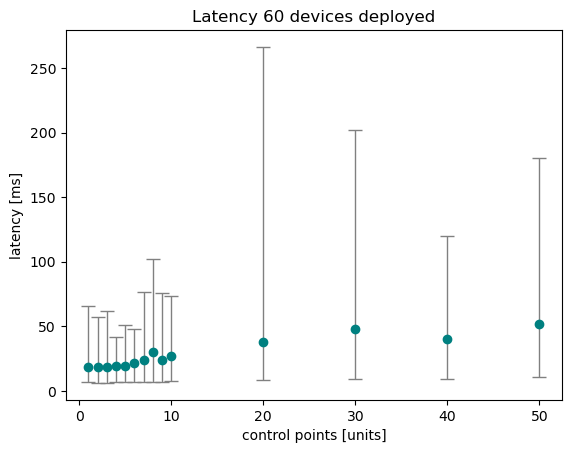

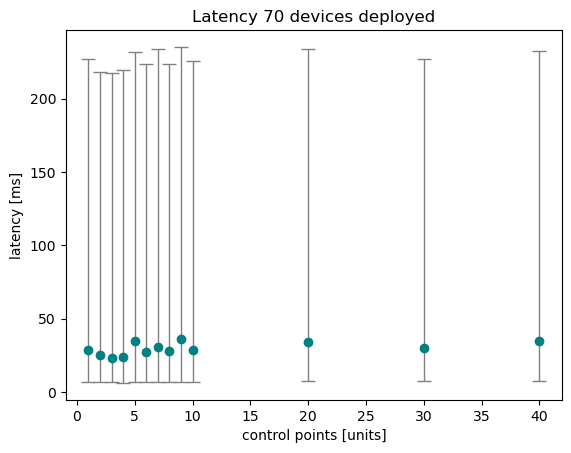

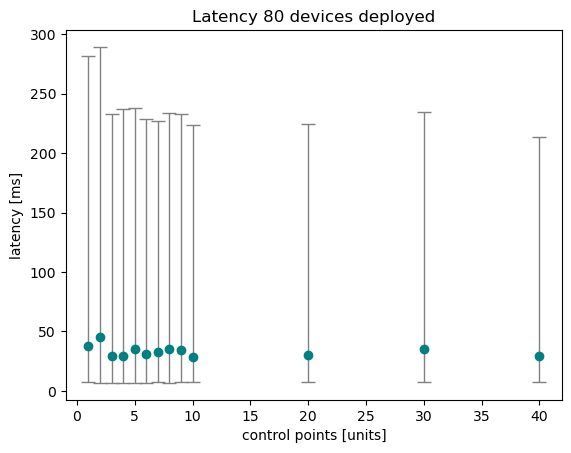

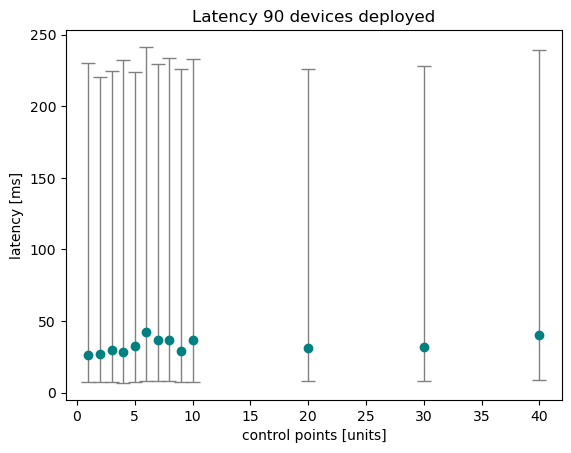

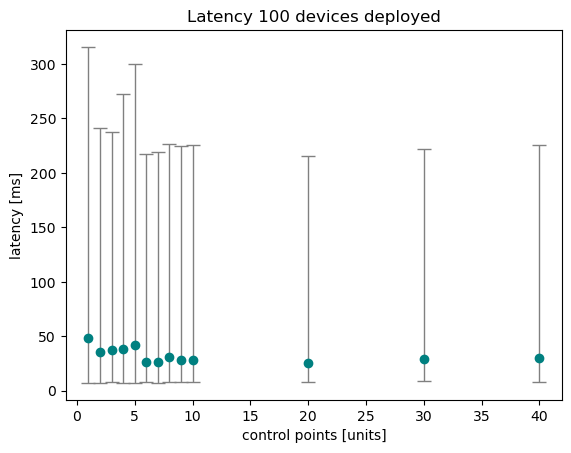

In [39]:
for device_config in device_configs:
    config = latency_data_pd[latency_data_pd["device_config"] == device_config]
    
    lower_error = [m - l for m, l in zip(config["average_value"], config["2.5_perc"])]
    upper_error = [u - m for m, u in zip(config["average_value"], config["97.5_perc"])]
    asymmetric_error = [lower_error, upper_error]

    plt.errorbar(config["control_config"],
                config["average_value"],
                yerr=asymmetric_error,
                fmt='o',
                color='teal',
                ecolor='grey',
                elinewidth=1,
                capsize=5
                )

    plt.title(f"Latency {device_config} devices deployed")
    plt.xlabel("control points [units]")
    plt.ylabel("latency [ms]")
    plt.show()

#### Robustness visualization

In [40]:
values_device = []
values_control = []

values_avg = []
values_max = []
values_min = []
fails_avg = []

values_avg_with_zero = []
fails_avg_with_zero = []

for device_config, controls in robustness_data.items():
    for control_config, tests in controls.items():
        values_device.append(device_config)
        values_control.append(control_config)

        mean_with_zero = np.mean(tests)
        fails_avg_with_zero.append(1 - mean_with_zero/device_config)
        values_avg_with_zero.append(mean_with_zero) 

robustness_data_pd = pd.DataFrame({"device_config": values_device,
                                   "control_config": values_control,
                                   "average_value_zero": values_avg_with_zero,
                                   "fails_avg_zero": fails_avg_with_zero
                                   }).sort_values(by=["device_config", "control_config"])

robustness_data_pd

,device_config,control_config,average_value_zero,fails_avg_zero
289,1,1,0.800000,0.200000
301,1,2,0.566667,0.433333
299,1,3,0.511111,0.488889
298,1,4,0.408333,0.591667
296,1,5,0.386667,0.613333
...,...,...,...,...
80,100,60,0.000000,1.000000
83,100,70,0.000000,1.000000
89,100,80,0.000000,1.000000
87,100,90,0.000000,1.000000


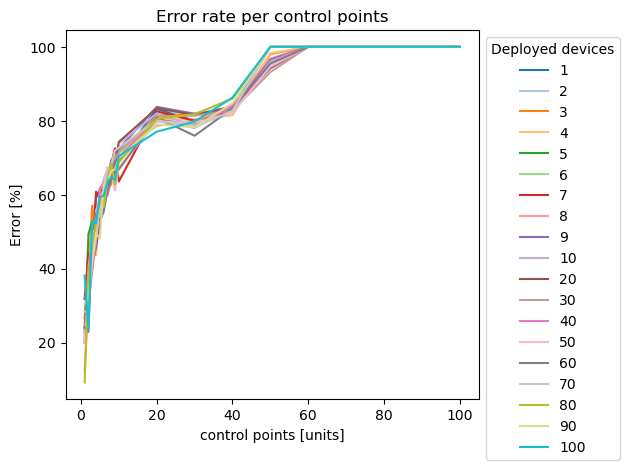

In [41]:
device_configs = robustness_data_pd["device_config"].unique()
device_configs.sort()

fig, ax = plt.subplots()

labels_colors = plt.cm.tab20(np.linspace(0, 1, 20))
count = 0
for device_config in device_configs:
    robustValues = robustness_data_pd[robustness_data_pd["device_config"] == device_config]

    ax.plot(robustValues["control_config"], robustValues["fails_avg_zero"]*100, label=f"{device_config}", color=labels_colors[count])

    count += 1

ax.set_title(f"Error rate per control points")
ax.set_xlabel("control points [units]")
ax.set_ylabel("Error [%]")
ax.legend(title="Deployed devices", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
    
plt.show()

## MQTT Analysis

### Data filtering

#### Filter latency related data

In [42]:
def filter_mqtt_latency(mqtt_tests: dict) -> dict:
    latency_data = {}

    for device_config, controls in mqtt_tests.items():
        latency_controls = {}
        for control_config, control_tests in controls.items():
            latency_qos = {}
            for qos_config, qos_tests in control_tests.items():
                latency_tests = []
                for test in qos_tests:
                    latency_values = []
                    for value in test:
                        match = re.search("Device switch elapsed set: [0-9]+(.[0-9]+)?.s$", value["msg"])
                        if match:
                            latency_values.append(convert_strings_to_milliseconds(match.group().split(":")[1].strip()))
                    
                    if len(latency_values) > 0:
                        latency_tests.append(latency_values)
                
                lens = np.array([len(item) for item in latency_tests])
                if len(lens) > 0:
                    mask = np.arange(lens.max()) < lens[:, None]
                    result = np.zeros(mask.shape, dtype=float)
                    result[mask] = np.concatenate(latency_tests)
                    latency_qos[qos_config] = result
            
            latency_controls[control_config] = latency_qos

        latency_data[device_config] = latency_controls
    
    return latency_data

In [43]:
latency_data = {}

for qos in range(0,3):
    for devices in range(1,10):
        mqtt_latency_part = filter_mqtt_latency(load_log_file(mqtt + f"/d-{devices}_q-{qos}"))

        for devices_key, devices_config in mqtt_latency_part.items():
            for controls_key, controls_config in devices_config.items():
                for qos_key, value in controls_config.items():
                    latency_data.setdefault(devices_key, {}).setdefault(controls_key, {})[qos_key] = value
    
    for devices in range(10,101,10):
        mqtt_latency_part = filter_mqtt_latency(load_log_file(mqtt + f"/d-{devices}_q-{qos}"))

        for devices_key, devices_config in mqtt_latency_part.items():
            for controls_key, controls_config in devices_config.items():
                for qos_key, value in controls_config.items():
                    latency_data.setdefault(devices_key, {}).setdefault(controls_key, {})[qos_key] = value

#### Filter robustness related data

In [44]:
def filter_mqtt_robustness(mqtt_tests: dict) -> dict:
    robustness_data = {}

    for device_config, controls in mqtt_tests.items():
        robustness_controls = {}
        for control_config, control_tests in controls.items():
            robustness_tests = {}
            for qos_config, qos_tests in control_tests.items():
                robustness_qos = []
                for test in qos_tests:
                    robustness_values = []
                    for value in test:
                        match = re.search("Mqtt search found [0-9]+", value["msg"])
                        if match:
                            robustness_values.append(match.group().removeprefix("Mqtt search found "))
                    
                    if len(robustness_values) > 0:
                        robustness_qos.append(robustness_values)
                
                lens = np.array([len(item) for item in robustness_qos])
                if len(lens) > 0:
                    mask = np.arange(lens.max()) < lens[:, None]
                    result = np.zeros(mask.shape, dtype=float)
                    result[mask] = np.concatenate(robustness_qos)
                    robustness_tests[qos_config] = result
            
            robustness_controls[control_config] = robustness_tests

        robustness_data[device_config] = robustness_controls

    return robustness_data


In [45]:
robustness_data = {}

for qos in range(0,3):
    for devices in range(1,10):
        mqtt_robustness_part = filter_mqtt_robustness(load_log_file(mqtt + f"/d-{devices}_q-{qos}"))

        for devices_key, devices_config in mqtt_robustness_part.items():
            for controls_key, controls_config in devices_config.items():
                for qos_key, value in controls_config.items():
                    robustness_data.setdefault(devices_key, {}).setdefault(controls_key, {})[qos_key] = value
    
    for devices in range(10,101,10):
        mqtt_robustness_part = filter_mqtt_robustness(load_log_file(mqtt + f"/d-{devices}_q-{qos}"))

        for devices_key, devices_config in mqtt_robustness_part.items():
            for controls_key, controls_config in devices_config.items():
                for qos_key, value in controls_config.items():
                    robustness_data.setdefault(devices_key, {}).setdefault(controls_key, {})[qos_key] = value

### Data visualization

#### Latency visualiazation

In [46]:
values_device = []
values_control = []
values_qos = []

values_avg = []
values_max = []
values_min = []
values_97_5 = []
values_2_5 = []

for device_config, controls in latency_data.items():
    for control_config, qos in controls.items():
        for qos_config, values in qos.items(): 
            values_device.append(device_config)
            values_control.append(control_config)
            values_qos.append(qos_config)

            values_avg.append(np.mean(values))
            values_max.append(np.max(values))
            values_min.append(np.min(values))

            value_2_5, value_97_5 = np.percentile(values, [2.5, 97.5])

            values_97_5.append(value_97_5)
            values_2_5.append(value_2_5)

        
latency_data_pd = pd.DataFrame({"device_config": values_device,
                                "control_config": values_control,
                                "qos_config": values_qos,
                                "average_value": values_avg,
                                "max_value": values_max,
                                "min_value": values_min,
                                "97.5_perc": values_97_5,
                                "2.5_perc": values_2_5
                                }).sort_values(by=["device_config","control_config","qos_config"])

latency_data_pd

,device_config,control_config,qos_config,average_value,max_value,min_value,97.5_perc,2.5_perc
9,1,1,0,510.863980,1033.262140,133.754604,1032.763304,135.055805
10,1,1,1,587.671471,1242.163150,220.541087,1226.694173,221.385766
11,1,1,2,710.111824,1460.506900,141.353130,1377.702642,193.632631
18,1,2,0,1002.306591,1959.798500,251.191183,1866.683902,326.667041
19,1,2,1,1124.818562,1966.102110,134.212149,1957.752890,199.724136
...,...,...,...,...,...,...,...,...
509,100,8,1,10.996457,65.347312,0.000000,41.214122,0.000000
510,100,9,0,10.706412,57.881793,0.000000,39.519923,0.000000
511,100,9,1,14.508984,70.165064,0.000000,49.905549,0.000000
512,100,10,0,15.895131,1537.786340,0.000000,46.289087,0.000000


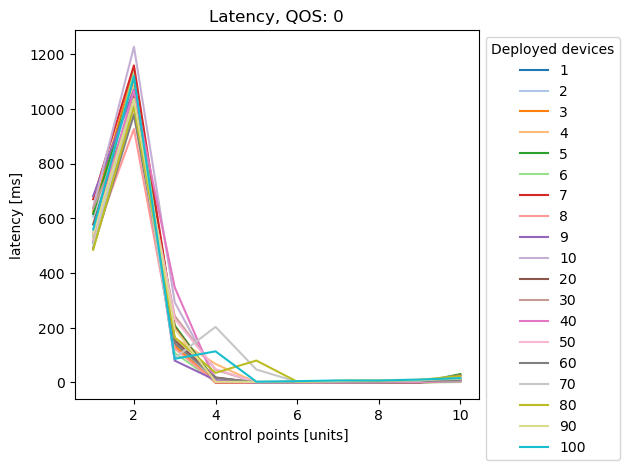

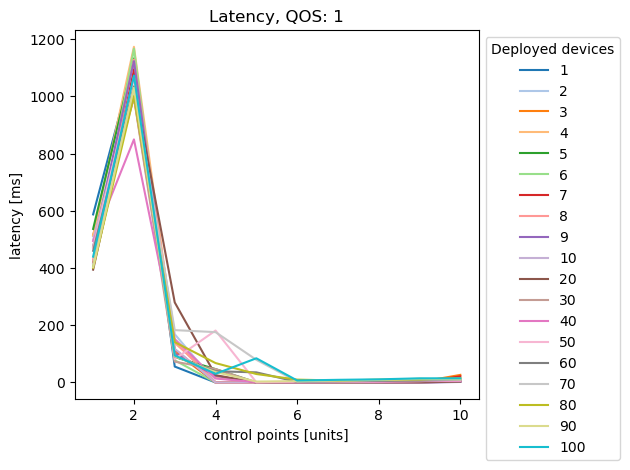

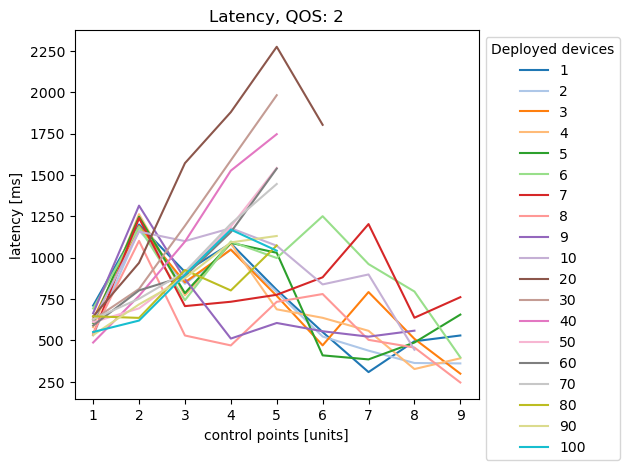

In [47]:
qos_configs = latency_data_pd["qos_config"].unique()
qos_configs.sort()

for qos_config in qos_configs:
    qos_values = latency_data_pd[latency_data_pd["qos_config"] == qos_config]

    device_configs = qos_values["device_config"].unique()
    device_configs.sort()

    fig, ax = plt.subplots()

    labels_colors = plt.cm.tab20(np.linspace(0, 1, 20))

    count = 0
    for device_config in device_configs:
        config = qos_values[qos_values["device_config"] == device_config]
        
        ax.plot(config["control_config"], config["average_value"], label=f"{device_config}", color=labels_colors[count])
        
        count += 1
        
    ax.set_title(f"Latency, QOS: {qos_config}")
    ax.set_xlabel("control points [units]")
    ax.set_ylabel("latency [ms]")
    ax.legend(title="Deployed devices", loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()    

    plt.show()

In [ ]:
for qos_config in qos_configs:
    for device_config in device_configs:
        config = latency_data_pd[(latency_data_pd["device_config"] == device_config) & (latency_data_pd["qos_config"] == qos_config)]
        
        lower_error = [m - l for m, l in zip(config["average_value"], config["2.5_perc"])]
        upper_error = [u - m for m, u in zip(config["average_value"], config["97.5_perc"])]
        asymmetric_error = [lower_error, upper_error]

        plt.errorbar(config["control_config"],
                    config["average_value"],
                    yerr=asymmetric_error,
                    fmt='o',
                    color='teal',
                    ecolor='grey',
                    elinewidth=1,
                    capsize=5
                    )

        plt.title(f"Latency {device_config} devices deployed")
        plt.xlabel("control points [units]")
        plt.ylabel("latency [ms]")
        plt.show()

#### Robustness visualization

In [49]:
values_device = []
values_control = []
values_qos = []

values_avg = []
values_max = []
values_min = []

values_avg_with_zero = []
fails_avg_with_zero = []

for device_config, controls in robustness_data.items():
    for control_config, qos in controls.items():
        for qos_config, values in qos.items(): 
            values_device.append(device_config)
            values_control.append(control_config)
            values_qos.append(qos_config)

            mean_with_zero = np.mean(values)
            fails_avg_with_zero.append(1 - mean_with_zero/(device_config * control_config))
            values_avg_with_zero.append(mean_with_zero)

        
robustness_data_pd = pd.DataFrame({"device_config": values_device,
                                   "control_config": values_control,
                                   "qos_config": values_qos,
                                   "average_value_zero": values_avg_with_zero,
                                   "fails_avg_zero": fails_avg_with_zero
                                   }).sort_values(by=["device_config","control_config","qos_config"])

robustness_data_pd

,device_config,control_config,qos_config,average_value_zero,fails_avg_zero
18,1,1,0,1.0,0.0
19,1,1,1,1.0,0.0
20,1,1,2,1.0,0.0
39,1,2,0,2.0,0.0
40,1,2,1,2.0,0.0
...,...,...,...,...,...
1081,100,90,1,0.0,1.0
1082,100,90,2,0.0,1.0
1041,100,100,0,0.0,1.0
1042,100,100,1,0.0,1.0


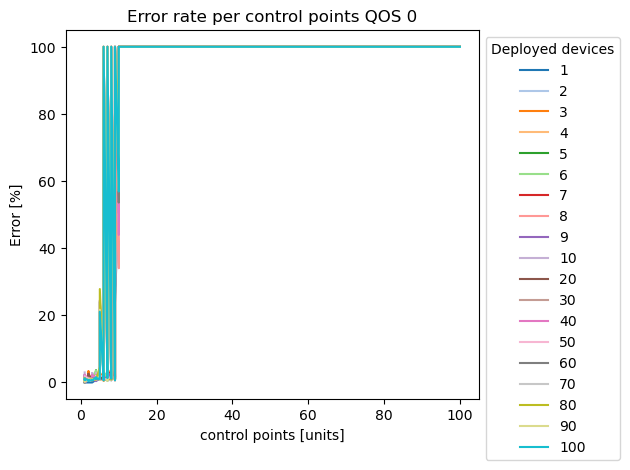

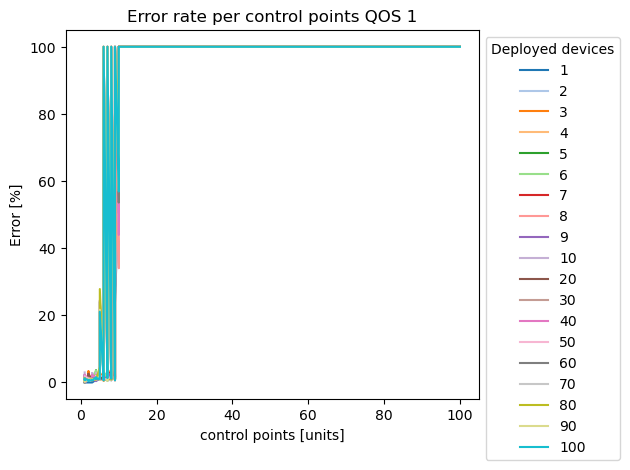

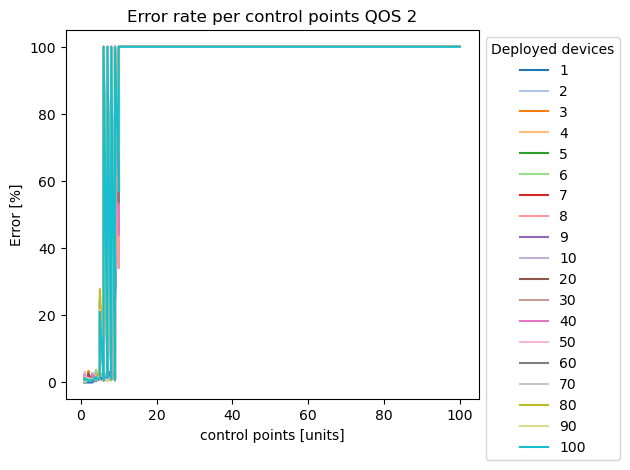

In [50]:
qos_configs = robustness_data_pd["qos_config"].unique()
qos_configs.sort()

for qos_config in qos_configs:
    qos_values = robustness_data_pd[robustness_data_pd["qos_config"] == qos_config]
    
    device_configs = robustness_data_pd["device_config"].unique()
    device_configs.sort()

    fig, ax = plt.subplots()

    labels_colors = plt.cm.tab20(np.linspace(0, 1, 20))
    count = 0
    for device_config in device_configs:
        robustValues = robustness_data_pd[robustness_data_pd["device_config"] == device_config]

        ax.plot(robustValues["control_config"], robustValues["fails_avg_zero"]*100, label=f"{device_config}", color=labels_colors[count])
        
        count += 1

    ax.set_title(f"Error rate per control points QOS {qos_config}")
    ax.set_xlabel("control points [units]")
    ax.set_ylabel("Error [%]")
    ax.legend(title="Deployed devices", loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()

    plt.show()